#### Setup

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from config import RAW_DIR, BRONZE_DIR, COLS_RIPS, COD_NO_DEFINIDO, TIPOS_ATENCION

# Configuracion visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

# Ruta exacta de tu archivo
CSV_PATH = RAW_DIR / "_RIPS_20260902.csv"
print(f"Archivo: {CSV_PATH}")
print(f"Existe: {CSV_PATH.exists()}")

Archivo: C:\Users\ASUS I7\Documents\rips-colombia-health-segmentation\notebooks\..\data\raw\_RIPS_20260902.csv
Existe: True


#### Inspeccion inicial con DuckDB

In [2]:
con = duckdb.connect()

# Verificar lectura
df_muestra = con.execute(f"""
    SELECT * FROM read_csv_auto('{CSV_PATH}')
    LIMIT 5
""").fetchdf()

print(df_muestra.columns.tolist())
df_muestra

['Departamento', 'Municipio', 'Año', 'TipoAtencion', 'Diagnostico', 'NumeroAtenciones']


,Departamento,Municipio,Año,TipoAtencion,Diagnostico,NumeroAtenciones
0,05 - Antioquia,05212 - Copacabana,2012,CONSULTAS,F431 - TRASTORNO DE ESTRÃ‰S POSTRAUMATICO,2
1,05 - Antioquia,05576 - Pueblorrico,2011,CONSULTAS,"C779 - TUMOR MALIGNO DEL GANGLIO LINFATICO, SI...",1
2,05 - Antioquia,05086 - Belmira,2014,PROCEDIMIENTOS DE SALUD,Z340 - SUPERVISION DE PRIMER EMBARAZO NORMAL,48
3,05 - Antioquia,05490 - NecoclÃ­,2015,CONSULTAS,M545 - LUMBAGO NO ESPECIFICADO,961
4,05 - Antioquia,05212 - Copacabana,2012,CONSULTAS,F510 - INSOMNIO NO ORGANICO,32


#### Conteo total

In [3]:
total_filas = con.execute(f"""
    SELECT COUNT(*) as total FROM read_csv_auto('{CSV_PATH}')
""").fetchone()[0]

print(f"Total de registros: {total_filas:,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total de registros: 38,000,000


#### Cardinalidad

In [5]:
cardinalidad = con.execute(f"""
    SELECT 
        COUNT(DISTINCT Departamento) as n_deptos,
        COUNT(DISTINCT Municipio) as n_municipios,
        COUNT(DISTINCT Año) as n_anios,
        COUNT(DISTINCT TipoAtencion) as n_tipos,
        COUNT(DISTINCT Diagnostico) as n_diagnosticos
    FROM read_csv_auto('{CSV_PATH}')
""").fetchdf()

print(cardinalidad)

print(f"\nTipos de atencion encontrados:")
print(con.execute(f"""
    SELECT DISTINCT TipoAtencion 
    FROM read_csv_auto('{CSV_PATH}')
""").fetchdf())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   n_deptos  n_municipios  n_anios  n_tipos  n_diagnosticos
0        27          1076       13        4           12642

Tipos de atencion encontrados:


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

              TipoAtencion
0                URGENCIAS
1                CONSULTAS
2  PROCEDIMIENTOS DE SALUD
3        HOSPITALIZACIONES


#### Estadisticas de NumeroAtenciones

In [6]:
stats = con.execute(f"""
    SELECT 
        MIN(NumeroAtenciones) as minimo,
        MAX(NumeroAtenciones) as maximo,
        AVG(NumeroAtenciones)::FLOAT as media,
        MEDIAN(NumeroAtenciones)::FLOAT as mediana,
        SUM(NumeroAtenciones)::FLOAT as total_atenciones
    FROM read_csv_auto('{CSV_PATH}')
""").fetchdf()

print(stats)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   minimo    maximo       media  mediana  total_atenciones
0       1  18619651  100.874161      3.0      3.833218e+09


#### El hallazgo critico: "NO DEFINIDO"

In [7]:
no_definido = con.execute(f"""
    SELECT 
        COUNT(*) as n_registros,
        SUM(NumeroAtenciones)::FLOAT as total_atenciones,
        COUNT(*) * 100.0 / (SELECT COUNT(*) FROM read_csv_auto('{CSV_PATH}')) as pct_registros,
        SUM(NumeroAtenciones) * 100.0 / (SELECT SUM(NumeroAtenciones) FROM read_csv_auto('{CSV_PATH}')) as pct_atenciones
    FROM read_csv_auto('{CSV_PATH}')
    WHERE Diagnostico = '{COD_NO_DEFINIDO}'
""").fetchdf()

print("=== IMPACTO DE 'NO DEFINIDO' ===")
print(no_definido)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== IMPACTO DE 'NO DEFINIDO' ===
   n_registros  total_atenciones  pct_registros  pct_atenciones
0        13422       986302592.0       0.035321       25.730407


#### Top 10 outliers por volumen

In [9]:
top_outliers = con.execute(f"""
    SELECT Departamento, Municipio, Año, TipoAtencion, Diagnostico, NumeroAtenciones
    FROM read_csv_auto('{CSV_PATH}')
    ORDER BY NumeroAtenciones DESC
    LIMIT 10
""").fetchdf()

print(top_outliers)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

         Departamento              Municipio   Año             TipoAtencion  \
0  11 - BogotÃ¡, D.C.  11001 - BogotÃ¡, D.C.  2018  PROCEDIMIENTOS DE SALUD   
1  11 - BogotÃ¡, D.C.  11001 - BogotÃ¡, D.C.  2018  PROCEDIMIENTOS DE SALUD   
2  11 - BogotÃ¡, D.C.  11001 - BogotÃ¡, D.C.  2019  PROCEDIMIENTOS DE SALUD   
3    -1 - NO DEFINIDO       -1 - No Definido  2020  PROCEDIMIENTOS DE SALUD   
4    -1 - NO DEFINIDO       -1 - No Definido  2020  PROCEDIMIENTOS DE SALUD   
5  11 - BogotÃ¡, D.C.  11001 - BogotÃ¡, D.C.  2014  PROCEDIMIENTOS DE SALUD   
6    -1 - NO DEFINIDO       -1 - No Definido  2018  PROCEDIMIENTOS DE SALUD   
7    -1 - NO DEFINIDO       -1 - No Definido  2018  PROCEDIMIENTOS DE SALUD   
8  11 - BogotÃ¡, D.C.  11001 - BogotÃ¡, D.C.  2012  PROCEDIMIENTOS DE SALUD   
9  11 - BogotÃ¡, D.C.  11001 - BogotÃ¡, D.C.  2015  PROCEDIMIENTOS DE SALUD   

       Diagnostico  NumeroAtenciones  
0  1 - NO DEFINIDO          18619651  
1  1 - NO DEFINIDO          18619651  
2  1 - NO DEF

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

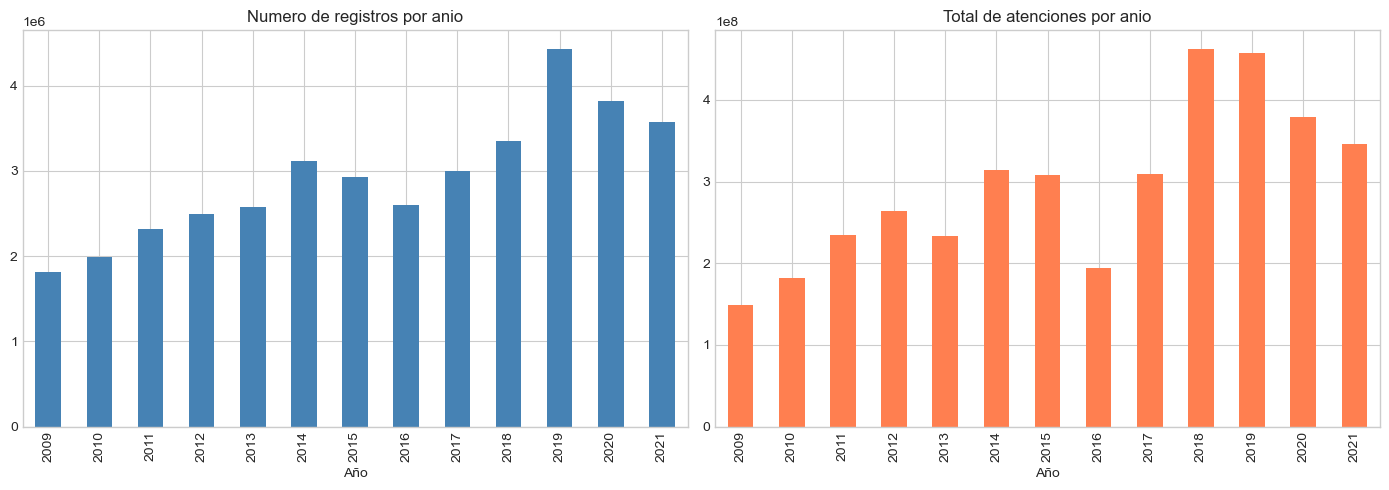

     Año  n_registros  total_atenciones
0   2009      1812166       149104864.0
1   2010      1987463       181435920.0
2   2011      2311618       234586496.0
3   2012      2498665       264363472.0
4   2013      2580455       233382688.0
5   2014      3118047       314410464.0
6   2015      2925912       307730816.0
7   2016      2600724       193751904.0
8   2017      2999972       309455232.0
9   2018      3349281       461931744.0
10  2019      4425099       457781664.0
11  2020      3822942       379289696.0
12  2021      3567656       345993088.0


In [14]:
por_anio = con.execute(f"""
    SELECT Año, COUNT(*) as n_registros, SUM(NumeroAtenciones)::FLOAT as total_atenciones
    FROM read_csv_auto('{CSV_PATH}')
    GROUP BY Año
    ORDER BY Año
""").fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

por_anio.plot(x='Año', y='n_registros', kind='bar', ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('Numero de registros por anio')
axes[0].set_xlabel('Año')

por_anio.plot(x='Año', y='total_atenciones', kind='bar', ax=axes[1], color='coral', legend=False)
axes[1].set_title('Total de atenciones por anio')
axes[1].set_xlabel('Año')

plt.tight_layout()
plt.savefig('../reports/figures/01_distribucion_anual.png', dpi=150, bbox_inches='tight')
plt.show()

print(por_anio)

In [15]:
# Crear carpeta de reports si no existe
Path('../reports/figures').mkdir(parents=True, exist_ok=True)

resumen = pd.DataFrame({
    'metrica': ['total_registros', 'total_atenciones', 'pct_no_definido_registros', 'pct_no_definido_atenciones'],
    'valor': [
        total_filas,
        stats['total_atenciones'].iloc[0],
        no_definido['pct_registros'].iloc[0],
        no_definido['pct_atenciones'].iloc[0]
    ]
})

resumen.to_csv('../reports/auditoria_resumen.csv', index=False)
print("Auditoria guardada en reports/auditoria_resumen.csv")
print(resumen)

Auditoria guardada en reports/auditoria_resumen.csv
                      metrica         valor
0             total_registros  3.800000e+07
1            total_atenciones  3.833218e+09
2   pct_no_definido_registros  3.532105e-02
3  pct_no_definido_atenciones  2.573041e+01
